## 03_luna_dataloader_basico.ipynb
 Objetivo:
 1) construir Dataset y DataLoader para LUNA16
 2) leer volúmenes .mhd correctamente
 3) aplicar preprocesado 3D robusto:
    - saneamiento HU
    - resampling con spacing real
    - clipping HU [-1000, 400]
    - normalización a [0,1]
    - ajuste final a 64x64x64
 4) devolver tensores listos para entrenamiento

## imports

In [21]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import SimpleITK as sitk
import scipy.ndimage as ndi

## configuración

In [22]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTS_DIR = DATA_DIR / "manifests"

MANIFEST_PATH = MANIFESTS_DIR / "manifest_luna16.csv"
SPLIT_PATH = MANIFESTS_DIR / "split_final_luna16.csv"

TARGET_SHAPE = (64, 64, 64)   # (D, H, W)
HU_MIN = -1000
HU_MAX = 400

# spacing objetivo para resampling físico antes del resize final
# (x, y, z) en mm
TARGET_SPACING = (1.0, 1.0, 1.25)

BATCH_SIZE = 2
NUM_WORKERS = 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("TARGET_SHAPE:", TARGET_SHAPE)
print("TARGET_SPACING:", TARGET_SPACING)

DEVICE: cuda
TARGET_SHAPE: (64, 64, 64)
TARGET_SPACING: (1.0, 1.0, 1.25)


## cargar manifest y split

In [23]:
manifest = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

df = manifest.merge(
    split_df[["seriesuid", "split"]],
    on="seriesuid",
    how="left"
)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nDistribución train:")
print(train_df["label_volume_binary"].value_counts())

train: (436, 15)
val: (93, 15)
test: (94, 15)

Distribución train:
label_volume_binary
1    300
0    136
Name: count, dtype: int64


## leer imagen .mhd

In [24]:
def read_ct_image(mhd_path):
    image = sitk.ReadImage(str(mhd_path))
    return image

## saneamiento HU en imagen SimpleITK

In [25]:
def sanitize_hu_sitk(image, lower_bound=-1024):
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]
    volume[volume < lower_bound] = lower_bound

    clean_image = sitk.GetImageFromArray(volume)
    clean_image.SetSpacing(image.GetSpacing())
    clean_image.SetOrigin(image.GetOrigin())
    clean_image.SetDirection(image.GetDirection())
    return clean_image

## resampling por spacing real

In [26]:
def resample_image_spacing(image, out_spacing=(1.0, 1.0, 1.25), is_label=False):
    original_spacing = image.GetSpacing()   # (x, y, z)
    original_size = image.GetSize()         # (x, y, z)

    out_size = [
        int(np.round(original_size[i] * (original_spacing[i] / out_spacing[i])))
        for i in range(3)
    ]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(image.GetDirection())
    resample.SetOutputOrigin(image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(float(-1024))

    if is_label:
        resample.SetInterpolator(sitk.sitkNearestNeighbor)
    else:
        resample.SetInterpolator(sitk.sitkLinear)

    return resample.Execute(image)

## clipping y normalización HU

In [27]:
def clip_and_normalize_hu(volume, hu_min=HU_MIN, hu_max=HU_MAX):
    volume = np.clip(volume, hu_min, hu_max)
    volume = (volume - hu_min) / (hu_max - hu_min)
    volume = np.clip(volume, 0.0, 1.0)
    return volume.astype(np.float32)

## resize final a shape fija

In [28]:
def resize_volume_to_shape(volume, target_shape=TARGET_SHAPE, order=1):
    d, h, w = volume.shape
    td, th, tw = target_shape

    zoom_factors = (
        td / d,
        th / h,
        tw / w,
    )

    resized = ndi.zoom(volume, zoom=zoom_factors, order=order)
    return resized.astype(np.float32)

## pipeline completo de preprocesado

In [29]:
def preprocess_ct_from_path(
    mhd_path,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE,
    hu_min=HU_MIN,
    hu_max=HU_MAX,
):
    # 1) leer
    image = read_ct_image(mhd_path)

    # 2) sanear HU raros
    image = sanitize_hu_sitk(image, lower_bound=-1024)

    # 3) resample físico por spacing
    image = resample_image_spacing(image, out_spacing=target_spacing, is_label=False)

    # 4) pasar a numpy
    volume = sitk.GetArrayFromImage(image).astype(np.float32)  # [D, H, W]

    # 5) clipping y normalización
    volume = clip_and_normalize_hu(volume, hu_min=hu_min, hu_max=hu_max)

    # 6) ajuste final a 64x64x64
    volume = resize_volume_to_shape(volume, target_shape=target_shape, order=1)

    return volume, image

## Dataset

In [30]:
class Luna16VolumeDataset(Dataset):
    def __init__(self, df, target_spacing=TARGET_SPACING, target_shape=TARGET_SHAPE):
        self.df = df.reset_index(drop=True).copy()
        self.target_spacing = target_spacing
        self.target_shape = target_shape

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        volume, processed_image = preprocess_ct_from_path(
            row["mhd_path"],
            target_spacing=self.target_spacing,
            target_shape=self.target_shape,
            hu_min=HU_MIN,
            hu_max=HU_MAX,
        )

        x = torch.from_numpy(volume).unsqueeze(0)  # [1, D, H, W]
        y = torch.tensor(int(row["label_volume_binary"]), dtype=torch.long)

        meta = {
            "seriesuid": row["seriesuid"],
            "subset": row["subset"],
            "split": row["split"],
            "mhd_path": row["mhd_path"],
            "processed_spacing_xyz": processed_image.GetSpacing(),
            "processed_size_xyz": processed_image.GetSize(),
        }

        return x, y, meta

## instanciar datasets

In [31]:
train_ds = Luna16VolumeDataset(
    train_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE
)

val_ds = Luna16VolumeDataset(
    val_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE
)

test_ds = Luna16VolumeDataset(
    test_df,
    target_spacing=TARGET_SPACING,
    target_shape=TARGET_SHAPE
)

print("len(train_ds):", len(train_ds))
print("len(val_ds):", len(val_ds))
print("len(test_ds):", len(test_ds))

len(train_ds): 436
len(val_ds): 93
len(test_ds): 94


## probar una muestra

In [32]:
x, y, meta = train_ds[0]

print("x.shape:", x.shape)   # [1, D, H, W]
print("y:", y.item())
print("meta:", meta)
print("x min/max:", float(x.min()), float(x.max()))
print("x dtype:", x.dtype)

x.shape: torch.Size([1, 64, 64, 64])
y: 0
meta: {'seriesuid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260', 'subset': 'subset0', 'split': 'train', 'mhd_path': '/mnt/d/Universidad/analitica/proyecto_analitica2/data/source/luna16/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd', 'processed_spacing_xyz': (1.0, 1.0, 1.25), 'processed_size_xyz': (390, 390, 242)}
x min/max: 0.0 1.0
x dtype: torch.float32


## visualización de muestra preprocesada

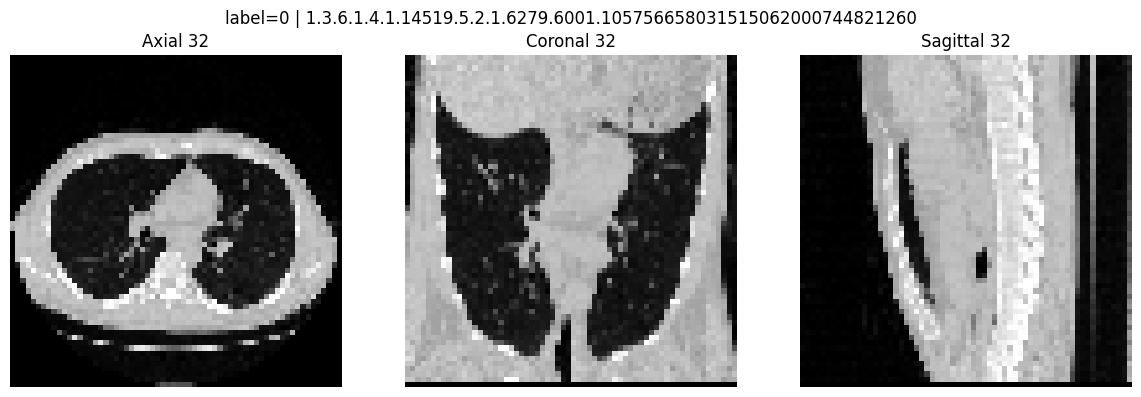

In [33]:
def show_processed_volume(x, title=""):
    vol = x.squeeze(0).numpy()  # [D, H, W]
    d, h, w = vol.shape
    dc, hc, wc = d // 2, h // 2, w // 2

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(vol[dc], cmap="gray")
    axes[0].set_title(f"Axial {dc}")
    axes[0].axis("off")

    axes[1].imshow(vol[:, hc, :], cmap="gray")
    axes[1].set_title(f"Coronal {hc}")
    axes[1].axis("off")

    axes[2].imshow(vol[:, :, wc], cmap="gray")
    axes[2].set_title(f"Sagittal {wc}")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_processed_volume(x, title=f"label={y.item()} | {meta['seriesuid']}")

## sampler balanceado para train

In [34]:
class_counts = train_df["label_volume_binary"].value_counts().sort_index().to_dict()
print("class_counts:", class_counts)

sample_weights = train_df["label_volume_binary"].map(
    lambda cls: 1.0 / class_counts[cls]
).values

train_sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

class_counts: {0: 136, 1: 300}


## collate function

In [35]:
def simple_collate(batch):
    xs, ys, metas = zip(*batch)
    xs = torch.stack(xs, dim=0)   # [B, 1, D, H, W]
    ys = torch.stack(ys, dim=0)   # [B]
    return xs, ys, metas

## DataLoaders

In [36]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=simple_collate
)

## probar un batch

In [37]:
xb, yb, metab = next(iter(train_loader))

print("xb.shape:", xb.shape)   # [B, 1, D, H, W]
print("yb.shape:", yb.shape)
print("yb:", yb.tolist())
print("xb min/max:", float(xb.min()), float(xb.max()))
print("xb dtype:", xb.dtype)

xb.shape: torch.Size([2, 1, 64, 64, 64])
yb.shape: torch.Size([2])
yb: [0, 1]
xb min/max: 0.0 1.0
xb dtype: torch.float32


## visualizar un ejemplo del batch

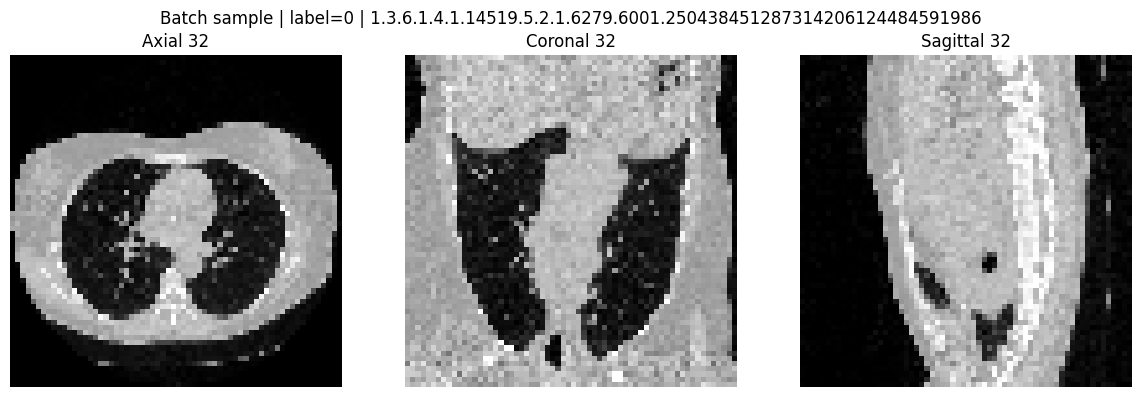

In [38]:
sample_idx = 0
show_processed_volume(
    xb[sample_idx],
    title=f"Batch sample | label={yb[sample_idx].item()} | {metab[sample_idx]['seriesuid']}"
)

## resumen final del notebook

In [39]:
print("Resumen final dataloader LUNA16")
print("-" * 40)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))
print("Target shape:", TARGET_SHAPE)
print("Target spacing:", TARGET_SPACING)
print("HU range:", (HU_MIN, HU_MAX))
print("Batch size:", BATCH_SIZE)
print("Device:", DEVICE)

Resumen final dataloader LUNA16
----------------------------------------
Train size: 436
Val size: 93
Test size: 94
Target shape: (64, 64, 64)
Target spacing: (1.0, 1.0, 1.25)
HU range: (-1000, 400)
Batch size: 2
Device: cuda
